In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Reshape, Conv2DTranspose, Conv2D, Flatten, LeakyReLU, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import albumentations as A
from collections import defaultdict, Counter
import tensorflow as tf
import gc

# GPU চেক
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ডেটাসেট পাথ
dataset_dir = '/kaggle/input/snake-dataset-35-classes-update/Snake Dataset'

# ক্লাস লিস্ট স্ক্যান
classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
num_classes = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print(f"Found {num_classes} classes: {classes}")

2025-08-17 12:43:51.574383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755434631.789302      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755434631.857919      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Num GPUs Available:  0
Found 35 classes: ['Indian wolf snake', 'Green cat-eyed snake', 'Stolatz_s keelback', 'Painted bronzeback', 'Spectacled cobra', 'Common Indian krait', 'White-lipped pit viper', 'Indian rock python', 'Grey cat snake', 'Russell_s viper', 'Banded krait', 'Red-necked keelback', 'Golden tree snake', 'Red sand boa', 'Brahminy blind snake', 'Golden flying snake', 'Indian krait', 'Saw-scaled viper', 'Indian gamma snake', 'Monocled cobra', 'Ornate flying snake', 'Indian cobra', 'Forsten_s cat snake', 'Common sand boa', 'Common wolf snake', 'Asian vine snake', 'Copperhead rat snake', 'Indian sand boa', 'Oriental rat snake', 'Checkered keelback', 'Common krait', 'Green vine snake', 'Common rat snake', 'Dog-faced water snake', 'King cobra']


2025-08-17 12:44:15.654345: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
image_paths = []
labels = []

for cls in classes:
    cls_dir = os.path.join(dataset_dir, cls)
    for img_file in os.listdir(cls_dir):
        if img_file.endswith('.jpg'):
            image_paths.append(os.path.join(cls_dir, img_file))
            labels.append(class_to_idx[cls])

print(f"Loaded {len(image_paths)} images from {num_classes} classes.")

# সেভ
np.save('/kaggle/working/image_paths.npy', image_paths)
np.save('/kaggle/working/labels.npy', labels)

Loaded 24864 images from 35 classes.


In [3]:
image_paths = np.load('/kaggle/working/image_paths.npy')
labels = np.load('/kaggle/working/labels.npy')

valid_paths = []
valid_labels = []
hashes = defaultdict(list)

for path, label in zip(image_paths, labels):
    try:
        img = Image.open(path)
        hash_val = imagehash.dhash(img)
        if str(hash_val) not in hashes or path not in hashes[str(hash_val)]:
            hashes[str(hash_val)].append(path)
            valid_paths.append(path)
            valid_labels.append(label)
    except Exception as e:
        print(f"Corrupted or invalid image: {path}, error: {e}")

image_paths = valid_paths
labels = valid_labels
print(f"After cleaning: {len(image_paths)} images.")

# সেভ
np.save('/kaggle/working/clean_image_paths.npy', image_paths)
np.save('/kaggle/working/clean_labels.npy', labels)

After cleaning: 24864 images.


In [4]:
# সেল ৪: ইমেজ রিসাইজিং এবং নর্মালাইজেশন
img_size = (224, 224)
batch_size = 100  # Kaggle মেমরি লিমিটের জন্য কমানো
image_paths = np.load('/kaggle/working/clean_image_paths.npy')
labels = np.load('/kaggle/working/clean_labels.npy')

# আউটপুট ফোল্ডার তৈরি
resized_dir = '/kaggle/working/resized_images'
os.makedirs(resized_dir, exist_ok=True)
for cls in classes:
    os.makedirs(os.path.join(resized_dir, cls), exist_ok=True)

# ব্যাচে রিসাইজ এবং সেভ
for i in range(0, len(image_paths), batch_size):
    batch_paths = image_paths[i:i+batch_size]
    batch_labels = labels[i:i+batch_size]
    for j, (path, label) in enumerate(zip(batch_paths, batch_labels)):
        try:
            img = load_img(path, target_size=img_size)
            img = img_to_array(img)
            img = (img / 127.5) - 1  # [-1, 1]
            # ফোল্ডারে সেভ
            cls_name = idx_to_class[label]
            save_path = os.path.join(resized_dir, cls_name, f'img_{i+j}.jpg')
            Image.fromarray(((img + 1) * 127.5).astype(np.uint8)).save(save_path)
        except Exception as e:
            print(f"Error processing image {path}: {e}")
    gc.collect()  # মেমরি ক্লিয়ার

# ফোল্ডার থেকে numpy অ্যারে তৈরি
X = []
y = []
for cls in classes:
    cls_dir = os.path.join(resized_dir, cls)
    for img_file in os.listdir(cls_dir):
        if img_file.endswith('.jpg'):
            img = load_img(os.path.join(cls_dir, img_file))
            img = img_to_array(img)
            img = (img / 127.5) - 1
            X.append(img)
            y.append(class_to_idx[cls])

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f"Resized and normalized: X shape {X.shape}, y shape {y.shape}")

# সেভ
np.save('/kaggle/working/X_resized_normalized.npy', X)
np.save('/kaggle/working/y.npy', y)

Resized and normalized: X shape (24864, 224, 224, 3), y shape (24864,)


In [5]:
augmented_dir = '/kaggle/working/augmented_dataset'
os.makedirs(augmented_dir, exist_ok=True)
for cls in classes:
    os.makedirs(os.path.join(augmented_dir, cls), exist_ok=True)

class_counts = Counter(labels)
minority_classes = [cls for cls, count in class_counts.items() if count < 100]
print("Class counts:", {idx_to_class[cls]: count for cls, count in class_counts.items()})
print("Minority classes:", [idx_to_class[cls] for cls in minority_classes])

transform = A.Compose([
    A.Rotate(limit=40, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

for cls in minority_classes:
    cls_paths = [p for p, l in zip(image_paths, labels) if l == cls]
    cls_name = idx_to_class[cls]
    for i, path in enumerate(cls_paths):
        img = load_img(path, target_size=img_size)
        img = img_to_array(img)
        img = (img / 127.5) - 1
        aug_img = transform(image=((img + 1) * 127.5).astype(np.uint8))['image']
        aug_img = (aug_img / 127.5) - 1
        aug_img = ((aug_img + 1) * 127.5).astype(np.uint8)
        pil_img = Image.fromarray(aug_img)
        save_path = os.path.join(augmented_dir, cls_name, f'aug_{i}_{os.path.basename(path)}')
        pil_img.save(save_path)
    gc.collect()

# আপডেটেড পাথ এবং লেবেল
image_paths = []
labels = []
for cls in classes:
    cls_dir = os.path.join(augmented_dir, cls)
    if os.path.exists(cls_dir):
        for img_file in os.listdir(cls_dir):
            if img_file.endswith('.jpg'):
                image_paths.append(os.path.join(cls_dir, img_file))
                labels.append(class_to_idx[cls])

print(f"After augmentation: {len(image_paths)} images")

# সেভ
np.save('/kaggle/working/aug_image_paths.npy', image_paths)
np.save('/kaggle/working/aug_labels.npy', labels)

Class counts: {'Indian wolf snake': 90, 'Green cat-eyed snake': 32, 'Stolatz_s keelback': 496, 'Painted bronzeback': 554, 'Spectacled cobra': 253, 'Common Indian krait': 1801, 'White-lipped pit viper': 1338, 'Indian rock python': 143, 'Grey cat snake': 25, 'Russell_s viper': 3470, 'Banded krait': 1561, 'Red-necked keelback': 965, 'Golden tree snake': 355, 'Red sand boa': 33, 'Brahminy blind snake': 555, 'Golden flying snake': 16, 'Indian krait': 378, 'Saw-scaled viper': 510, 'Indian gamma snake': 193, 'Monocled cobra': 1162, 'Ornate flying snake': 39, 'Indian cobra': 3058, 'Forsten_s cat snake': 30, 'Common sand boa': 96, 'Common wolf snake': 105, 'Asian vine snake': 561, 'Copperhead rat snake': 649, 'Indian sand boa': 119, 'Oriental rat snake': 912, 'Checkered keelback': 232, 'Common krait': 195, 'Green vine snake': 152, 'Common rat snake': 144, 'Dog-faced water snake': 66, 'King cobra': 4576}
Minority classes: ['Indian wolf snake', 'Green cat-eyed snake', 'Grey cat snake', 'Red sand 

In [6]:
latent_dim = 100

def build_generator():
    model = Sequential()
    model.add(Dense(256 * 14 * 14, input_dim=latent_dim))  # বড় ইনিশিয়াল ডাইমেনশন
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((14, 14, 256)))
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))  # 14x14 -> 28x28
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2DTranspose(64, (4,4), strides=(2,2), padding='same'))   # 28x28 -> 56x56
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2DTranspose(32, (4,4), strides=(2,2), padding='same'))   # 56x56 -> 112x112
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2DTranspose(32, (4,4), strides=(2,2), padding='same'))   # 112x112 -> 224x224
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(3, (3,3), padding='same', activation='tanh'))          # 224x224x3
    return model

def build_discriminator():
    model = Sequential()
    model.add(Conv2D(32, (3,3), strides=(2,2), padding='same', input_shape=(224,224,3)))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Conv2D(64, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    return model

generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

# XAI: মডেল স্ট্রাকচার (explainability)
generator.summary()
discriminator.summary()

# সেভ
generator.save('/kaggle/working/generator_model.h5')
discriminator.save('/kaggle/working/discriminator_model.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50176)          │     5,067,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 56, 56, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 112, 112, 32)   │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 224, 224, 32)   │        16,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,773,411 (22.02 MB)

 Trainable params: 5,773,411 (22.02 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │       200,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,097 (859.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 220,097 (859.75 KB)

Minority classes: ['Indian wolf snake', 'Green cat-eyed snake', 'Grey cat snake', 'Red sand boa', 'Golden flying snake', 'Ornate flying snake', 'Forsten_s cat snake', 'Common sand boa', 'Dog-faced water snake']


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Class Indian wolf snake, Epoch 0: D loss real [array(0.6356001, dtype=float32), array(0., dtype=float32)], fake [array(0.6644174, dtype=float32), array(0.1875, dtype=float32)], G loss 0.6929622888565063
Class Indian wolf snake, Epoch 10: D loss real [array(0.65887123, dtype=float32), array(0.01785714, dtype=float32)], fake [array(0.66098875, dtype=float32), array(0.01704546, dtype=float32)], G loss 0.6888715624809265
Class Indian wolf snake, Epoch 20: D loss real [array(0.6725026, dtype=float32), array(0.00914634, dtype=float32)], fake [array(0.67670643, dtype=float32), array(0.00892857, dtype=float32)], G loss 0.6632794141769409
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 547ms/step
Class Green cat-eyed snake, Epoch 0: D loss real [array(0.7433348, dtype=float32), array(0.00614754, dtype=float32)], fake [array(0.75454515, dtype=float32), array(0.00604839, dtype=float32)], G loss 0.5657410621643066
Class Green cat-eyed snake, Epoch 10: D loss real [array(0.85844195, dtype=float32), array(0.00462963, d

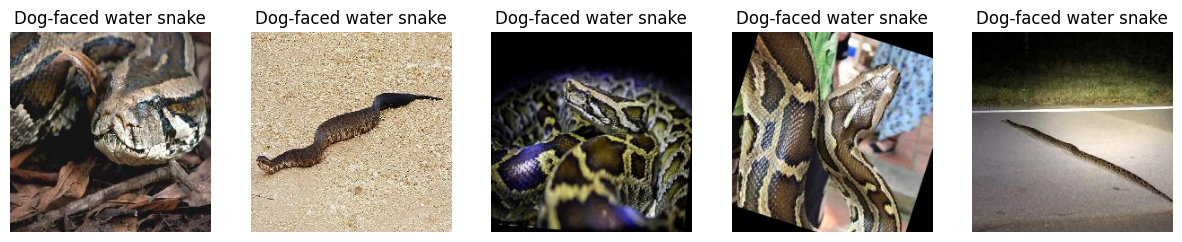

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import gc
from collections import Counter

# লোড
image_paths = np.load('/kaggle/working/aug_image_paths.npy')
labels = np.load('/kaggle/working/aug_labels.npy')

# GAN ফোল্ডার
gan_dir = '/kaggle/working/gan_dataset'
os.makedirs(gan_dir, exist_ok=True)
for cls in classes:
    os.makedirs(os.path.join(gan_dir, cls), exist_ok=True)

# মাইনরিটি ক্লাস
class_counts = Counter(labels)
minority_classes = [cls for cls, count in class_counts.items() if count < 100]
print("Minority classes:", [idx_to_class[cls] for cls in minority_classes])

# GAN ট্রেনিং
latent_dim = 100
for cls in minority_classes:
    cls_paths = [p for p, l in zip(image_paths, labels) if l == cls]
    if len(cls_paths) < 10:
        print(f"Skipping class {idx_to_class[cls]}: too few images ({len(cls_paths)})")
        continue
    cls_X = []
    for path in cls_paths:
        try:
            img = load_img(path, target_size=(224, 224))
            img = img_to_array(img)
            img = (img / 127.5) - 1  # [-1, 1]
            cls_X.append(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
    cls_X = np.array(cls_X)
    epochs = 30
    batch_size = 8
    for epoch in range(epochs):
        idx = np.random.randint(0, len(cls_X), batch_size)
        real_imgs = cls_X[idx]
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        fake_imgs = generator.predict(noise, verbose=0)
        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
        if epoch % 10 == 0:
            print(f"Class {idx_to_class[cls]}, Epoch {epoch}: D loss real {d_loss_real}, fake {d_loss_fake}, G loss {g_loss}")
    
    # সিন্থেটিক ইমেজ জেনারেট
    noise = np.random.normal(0, 1, (100, latent_dim))
    generated = generator.predict(noise)
    cls_name = idx_to_class[cls]
    for i, img in enumerate(generated):
        img = ((img + 1) * 127.5).astype(np.uint8)
        pil_img = Image.fromarray(img)
        pil_img.save(os.path.join(gan_dir, cls_name, f'gan_{i}.jpg'))
    del cls_X
    gc.collect()

# আপডেটেড পাথ এবং লেবেল (GAN + অগমেন্টেড)
image_paths = []
labels = []
for cls in classes:
    cls_dir = os.path.join(gan_dir, cls)
    if os.path.exists(cls_dir):
        for img_file in os.listdir(cls_dir):
            if img_file.endswith('.jpg'):
                image_paths.append(os.path.join(cls_dir, img_file))
                labels.append(class_to_idx[cls])

# আগের অগমেন্টেড ডেটা যোগ করুন
augmented_dir = '/kaggle/working/augmented_dataset'
for cls in classes:
    cls_dir = os.path.join(augmented_dir, cls)
    if os.path.exists(cls_dir):
        for img_file in os.listdir(cls_dir):
            if img_file.endswith('.jpg'):
                image_paths.append(os.path.join(cls_dir, img_file))
                labels.append(class_to_idx[cls])

print(f"After GAN integration: {len(image_paths)} images")

# NumPy অ্যারে তৈরি (মেমরি অপটিমাইজড)
batch_size = 100
X = []
y = labels
for i in range(0, len(image_paths), batch_size):
    batch_paths = image_paths[i:i+batch_size]
    batch_X = np.zeros((len(batch_paths), 224, 224, 3), dtype=np.float32)
    for j, path in enumerate(batch_paths):
        try:
            img = load_img(path, target_size=(224, 224))
            img = img_to_array(img)
            img = (img / 127.5) - 1
            batch_X[j] = img
        except Exception as e:
            print(f"Error loading {path}: {e}")
    X.append(batch_X)
    gc.collect()
X = np.concatenate(X, axis=0)

# XAI: Visualize
sample_paths = image_paths[-5:]
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i, path in enumerate(sample_paths):
    img = load_img(path)
    img = img_to_array(img)
    axs[i].imshow(img.astype(np.uint8))
    axs[i].set_title(idx_to_class[labels[-5+i]])
    axs[i].axis('off')
plt.show()

# সেভ
np.save('/kaggle/working/X_gan_integrated.npy', X)
np.save('/kaggle/working/y_gan_integrated.npy', y)
np.save('/kaggle/working/gan_image_paths.npy', image_paths)
np.save('/kaggle/working/gan_labels.npy', labels)
generator.save('/kaggle/working/generator_trained.h5')
discriminator.save('/kaggle/working/discriminator_trained.h5')

In [8]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

# লোড
X = np.load('/kaggle/working/X_gan_integrated.npy')
y = np.load('/kaggle/working/y_gan_integrated.npy')

# স্প্লিট
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# সেভ: NumPy
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/X_val.npy', X_val)
np.save('/kaggle/working/y_val.npy', y_val)
np.save('/kaggle/working/X_test.npy', X_test)
np.save('/kaggle/working/y_test.npy', y_test)

# ফোল্ডারে সেভ
output_dir = '/kaggle/working/preprocessed_dataset'
os.makedirs(output_dir, exist_ok=True)
splits = [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]

for split, X_split, y_split in splits:
    split_dir = os.path.join(output_dir, split)
    os.makedirs(split_dir, exist_ok=True)
    for cls in classes:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)
    for i, (img, label) in enumerate(zip(X_split, y_split)):
        img = ((img + 1) * 127.5).astype(np.uint8)
        pil_img = Image.fromarray(img)
        cls_name = idx_to_class[label]
        pil_img.save(os.path.join(split_dir, cls_name, f'img_{i}.jpg'))

print("Preprocessing complete! Download from /kaggle/working/preprocessed_dataset/")

Train: 928, Val: 199, Test: 200
Preprocessing complete! Download from /kaggle/working/preprocessed_dataset/
